SQL- Python Script

Import Libraries

In [ ]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import requests
import os
import plotly.express as px

Connect to Duckdb

In [3]:

conn = duckdb.connect("wine_database.duckdb")
cur = conn.cursor()

Download France GeoJSON

In [4]:
import os
os.makedirs("data", exist_ok=True)

url = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_FRA_1.json"
response = requests.get(url)

with open("data/france_regions.geojson", "wb") as f:
    f.write(response.content)

print("Saved to data/france_regions.geojson")


Saved to data/france_regions.geojson


Load GeoJSON

In [5]:
gdf = gpd.read_file("data/france_regions.geojson")
gdf.head()



,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,FRA.1_1,FRA,France,Auvergne-Rhône-Alpes,NA,NA,Région,Region,NA,FR.AR,NA,"MULTIPOLYGON (((5.4158 44.1547, 5.397 44.1523,..."
1,FRA.2_1,FRA,France,Bourgogne-Franche-Comté,NA,NA,Région,Region,NA,FR.BF,NA,"MULTIPOLYGON (((5.2563 46.4519, 5.248 46.4594,..."
2,FRA.3_1,FRA,France,Bretagne,NA,NA,Région,Region,NA,FR.BT,FR-BRE,"MULTIPOLYGON (((-2.8357 47.3243, -2.8374 47.32..."
3,FRA.4_1,FRA,France,Centre-ValdeLoire,NA,NA,Région,Region,NA,FR.CN,FR-CVL,"MULTIPOLYGON (((2.0635 46.4213, 2.0485 46.4208..."
4,FRA.5_1,FRA,France,Corse,Corsica,NA,Région,Region,NA,FR.CE,FR-20R,"MULTIPOLYGON (((9.1021 41.426, 9.101 41.426, 9..."


In [6]:
# Inspect region names in GeoJson
# ----------------------------------------
# 5. Inspect region names in GeoJSON
# ----------------------------------------
sorted(gdf["NAME_1"].unique())


['Auvergne-Rhône-Alpes',
 'Bourgogne-Franche-Comté',
 'Bretagne',
 'Centre-ValdeLoire',
 'Corse',
 'GrandEst',
 'Hauts-de-France',
 'Normandie',
 'Nouvelle-Aquitaine',
 'Occitanie',
 'PaysdelaLoire',
 "Provence-Alpes-Côted'Azur",
 'Île-de-France']

In [7]:
# Normalize the names that we need for our dataset
# ----------------------------------------
# 6. Normalize GeoJSON region names
# ----------------------------------------
gdf["admin_region"] = gdf["NAME_1"].replace({
    "GrandEst": "Grand Est",
    "PaysdelaLoire": "Pays de la Loire",
    "Auvergne-Rhône-Alpes": "Auvergne-Rhône-Alpes",
    "Bourgogne-Franche-Comté": "Bourgogne-Franche-Comté",
    "Nouvelle-Aquitaine": "Nouvelle-Aquitaine"
})


In [8]:
# Vivino regions
regions = pd.DataFrame({
    "region": [
        "Alsace",
        "Bordeaux",
        "Bourgogne",
        "Chablis",
        "Champagne",
        "Côte De Beaune",
        "Loire Valley",
        "Pessac-Léognan",
        "Rhone Valley"
    ]
})
regions


,region
0,Alsace
1,Bordeaux
2,Bourgogne
3,Chablis
4,Champagne
5,Côte De Beaune
6,Loire Valley
7,Pessac-Léognan
8,Rhone Valley


In [9]:
# Mapping Vivino regions to Admin Regions
mapping = {
    "Alsace": "Grand Est",
    "Champagne": "Grand Est",
    "Bourgogne": "Bourgogne-Franche-Comté",
    "Chablis": "Bourgogne-Franche-Comté",
    "Côte De Beaune": "Bourgogne-Franche-Comté",
    "Bordeaux": "Nouvelle-Aquitaine",
    "Pessac-Léognan": "Nouvelle-Aquitaine",
    "Loire Valley": "Pays de la Loire",
    "Rhone Valley": "Auvergne-Rhône-Alpes"
}

regions["admin_region"] = regions["region"].map(mapping)
regions


,region,admin_region
0,Alsace,Grand Est
1,Bordeaux,Nouvelle-Aquitaine
2,Bourgogne,Bourgogne-Franche-Comté
3,Chablis,Bourgogne-Franche-Comté
4,Champagne,Grand Est
5,Côte De Beaune,Bourgogne-Franche-Comté
6,Loire Valley,Pays de la Loire
7,Pessac-Léognan,Nouvelle-Aquitaine
8,Rhone Valley,Auvergne-Rhône-Alpes


In [10]:
# Merge the regions of GeoJSON and Vivino Regions
# ----------------------------------------
# 7. Merge wine regions with map
# ----------------------------------------
merged = gdf.merge(regions, on="admin_region", how="right")
merged


,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry,admin_region,region
0,FRA.6_1,FRA,France,GrandEst,NA,NA,Région,Region,NA,FR.AO,NA,"MULTIPOLYGON (((7.1783 47.4581, 7.178 47.4681,...",Grand Est,Alsace
1,FRA.10_1,FRA,France,Nouvelle-Aquitaine,NA,NA,Région,Region,NA,FR.AC,FR-NAQ,"MULTIPOLYGON (((-0.1578 43.5814, -0.151 43.585...",Nouvelle-Aquitaine,Bordeaux
2,FRA.2_1,FRA,France,Bourgogne-Franche-Comté,NA,NA,Région,Region,NA,FR.BF,NA,"MULTIPOLYGON (((5.2563 46.4519, 5.248 46.4594,...",Bourgogne-Franche-Comté,Bourgogne
3,FRA.2_1,FRA,France,Bourgogne-Franche-Comté,NA,NA,Région,Region,NA,FR.BF,NA,"MULTIPOLYGON (((5.2563 46.4519, 5.248 46.4594,...",Bourgogne-Franche-Comté,Chablis
4,FRA.6_1,FRA,France,GrandEst,NA,NA,Région,Region,NA,FR.AO,NA,"MULTIPOLYGON (((7.1783 47.4581, 7.178 47.4681,...",Grand Est,Champagne
5,FRA.2_1,FRA,France,Bourgogne-Franche-Comté,NA,NA,Région,Region,NA,FR.BF,NA,"MULTIPOLYGON (((5.2563 46.4519, 5.248 46.4594,...",Bourgogne-Franche-Comté,Côte De Beaune
6,FRA.12_1,FRA,France,PaysdelaLoire,NA,NA,Région,Region,NA,FR.PL,NA,"MULTIPOLYGON (((-1.1979 46.2979, -1.2068 46.28...",Pays de la Loire,Loire Valley
7,FRA.10_1,FRA,France,Nouvelle-Aquitaine,NA,NA,Région,Region,NA,FR.AC,FR-NAQ,"MULTIPOLYGON (((-0.1578 43.5814, -0.151 43.585...",Nouvelle-Aquitaine,Pessac-Léognan
8,FRA.1_1,FRA,France,Auvergne-Rhône-Alpes,NA,NA,Région,Region,NA,FR.AR,NA,"MULTIPOLYGON (((5.4158 44.1547, 5.397 44.1523,...",Auvergne-Rhône-Alpes,Rhone Valley


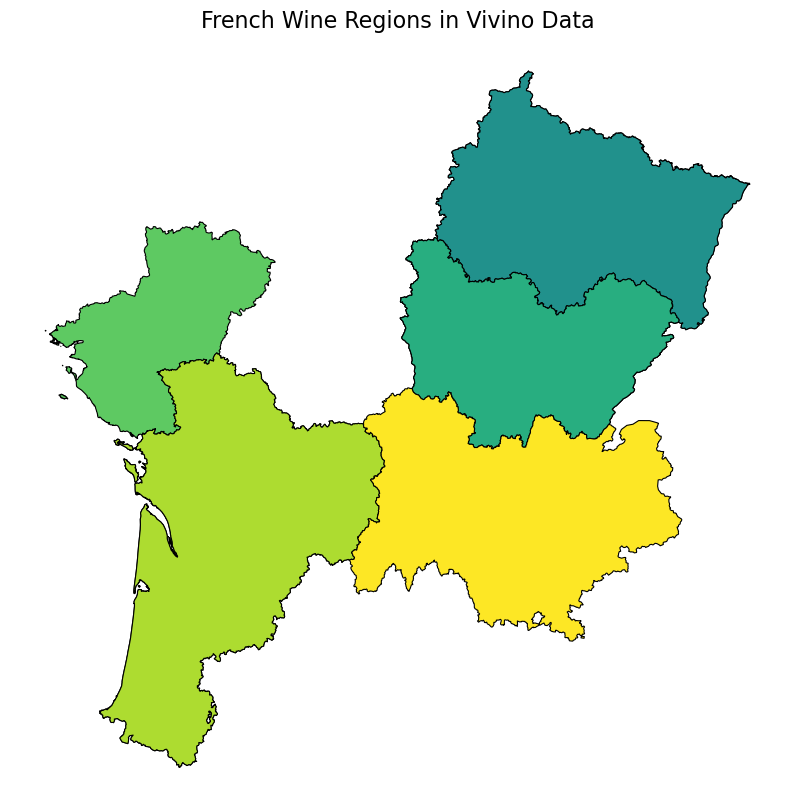

In [11]:
# ----------------------------------------
# 8. Plot French wine regions
# ----------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column="region",
    cmap="viridis",
    linewidth=0.8,
    edgecolor="black",
    legend=False,
    ax=ax
)

ax.set_title("French Wine Regions in Vivino Data", fontsize=16)
ax.axis("off")

plt.show()


In [12]:
# Step 1 - Compute Top Wine per Region
# Top wine per region (France only)
top_wines = conn.execute("""
    SELECT region,
           wine_name,
           winery_name,
           rating,
           ratings_count
    FROM vivino_clean
    WHERE country = 'France'
    QUALIFY ROW_NUMBER() OVER (PARTITION BY region ORDER BY rating DESC, ratings_count DESC) = 1
""").df()

top_wines


,region,wine_name,winery_name,rating,ratings_count
0,Alsace,Gewürztraminer Sélection De Grains Nobles Quin...,Leon Beyer,4.8,27
1,Rhone Valley,Le Viognier,Piaugier,4.5,39
2,Champagne,P3 Plénitude Brut Champagne,Dom Pérignon,4.9,83
3,Bordeaux,Eau-De-Vie De Prunes,Château Mouton Rothschild,4.5,338
4,Chablis,Domaine Jean De Bosmel Chablis,Louis Moreau,4.5,107
5,Pessac-Léognan,Pessac-Léognan (Premier Grand Cru Classé),Château Haut-Brion,4.6,48312
6,Bourgogne,Cuvée Simone,Château De Pommard,4.6,436
7,Loire Valley,Douceur,Vignoble Cogné - Domaine De La Couperie,4.6,35
8,Côte De Beaune,Côte De Beaune Les Pierres Blanches Blanc,Domaine De La Vougeraie,4.4,84


In [13]:
# Step 2 - Merge top wines into the map
merged_info = merged.merge(top_wines, on="region", how="left")
merged_info


,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry,admin_region,region,wine_name,winery_name,rating,ratings_count
0,FRA.6_1,FRA,France,GrandEst,NA,NA,Région,Region,NA,FR.AO,NA,"MULTIPOLYGON (((7.1783 47.4581, 7.178 47.4681,...",Grand Est,Alsace,Gewürztraminer Sélection De Grains Nobles Quin...,Leon Beyer,4.8,27
1,FRA.10_1,FRA,France,Nouvelle-Aquitaine,NA,NA,Région,Region,NA,FR.AC,FR-NAQ,"MULTIPOLYGON (((-0.1578 43.5814, -0.151 43.585...",Nouvelle-Aquitaine,Bordeaux,Eau-De-Vie De Prunes,Château Mouton Rothschild,4.5,338
2,FRA.2_1,FRA,France,Bourgogne-Franche-Comté,NA,NA,Région,Region,NA,FR.BF,NA,"MULTIPOLYGON (((5.2563 46.4519, 5.248 46.4594,...",Bourgogne-Franche-Comté,Bourgogne,Cuvée Simone,Château De Pommard,4.6,436
3,FRA.2_1,FRA,France,Bourgogne-Franche-Comté,NA,NA,Région,Region,NA,FR.BF,NA,"MULTIPOLYGON (((5.2563 46.4519, 5.248 46.4594,...",Bourgogne-Franche-Comté,Chablis,Domaine Jean De Bosmel Chablis,Louis Moreau,4.5,107
4,FRA.6_1,FRA,France,GrandEst,NA,NA,Région,Region,NA,FR.AO,NA,"MULTIPOLYGON (((7.1783 47.4581, 7.178 47.4681,...",Grand Est,Champagne,P3 Plénitude Brut Champagne,Dom Pérignon,4.9,83
5,FRA.2_1,FRA,France,Bourgogne-Franche-Comté,NA,NA,Région,Region,NA,FR.BF,NA,"MULTIPOLYGON (((5.2563 46.4519, 5.248 46.4594,...",Bourgogne-Franche-Comté,Côte De Beaune,Côte De Beaune Les Pierres Blanches Blanc,Domaine De La Vougeraie,4.4,84
6,FRA.12_1,FRA,France,PaysdelaLoire,NA,NA,Région,Region,NA,FR.PL,NA,"MULTIPOLYGON (((-1.1979 46.2979, -1.2068 46.28...",Pays de la Loire,Loire Valley,Douceur,Vignoble Cogné - Domaine De La Couperie,4.6,35
7,FRA.10_1,FRA,France,Nouvelle-Aquitaine,NA,NA,Région,Region,NA,FR.AC,FR-NAQ,"MULTIPOLYGON (((-0.1578 43.5814, -0.151 43.585...",Nouvelle-Aquitaine,Pessac-Léognan,Pessac-Léognan (Premier Grand Cru Classé),Château Haut-Brion,4.6,48312
8,FRA.1_1,FRA,France,Auvergne-Rhône-Alpes,NA,NA,Région,Region,NA,FR.AR,NA,"MULTIPOLYGON (((5.4158 44.1547, 5.397 44.1523,...",Auvergne-Rhône-Alpes,Rhone Valley,Le Viognier,Piaugier,4.5,39


In [14]:
# Step 3 - Convert to GeoJSCON for Plotly
merged_info_json = merged_info.to_json()

In [15]:
# Ensure region columns are synonimous

cur.execute("""ALTER TABLE winemag_clean 
            ADD COLUMN region_clean TEXT;
UPDATE winemag_clean
SET region_clean = 
    CASE 
        WHEN region_1 IS NOT NULL AND region_1 <> '' THEN region_1
        ELSE region_2
    END;
""")

CatalogException: Catalog Error: Column with name region_clean already exists!

In [19]:
cur.execute("""UPDATE winemag_clean
SET region_clean = 
    CASE
        WHEN region_clean = 'Loire Valley' THEN 'Loire'
        WHEN region_clean = 'Bourgogne' THEN 'Burgundy'
        WHEN region_clean = 'Cote de Beaune' THEN 'Côte De Beaune'
        ELSE region_clean
    END;

""")

In [20]:
cur.execute("""
SELECT *
FROM grape_quality_clean g
JOIN winemag_clean w
  ON g.region = w.region_clean;
            """)

C:\Users\joshu\AppData\Local\Temp\ipykernel_29244\2709135143.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


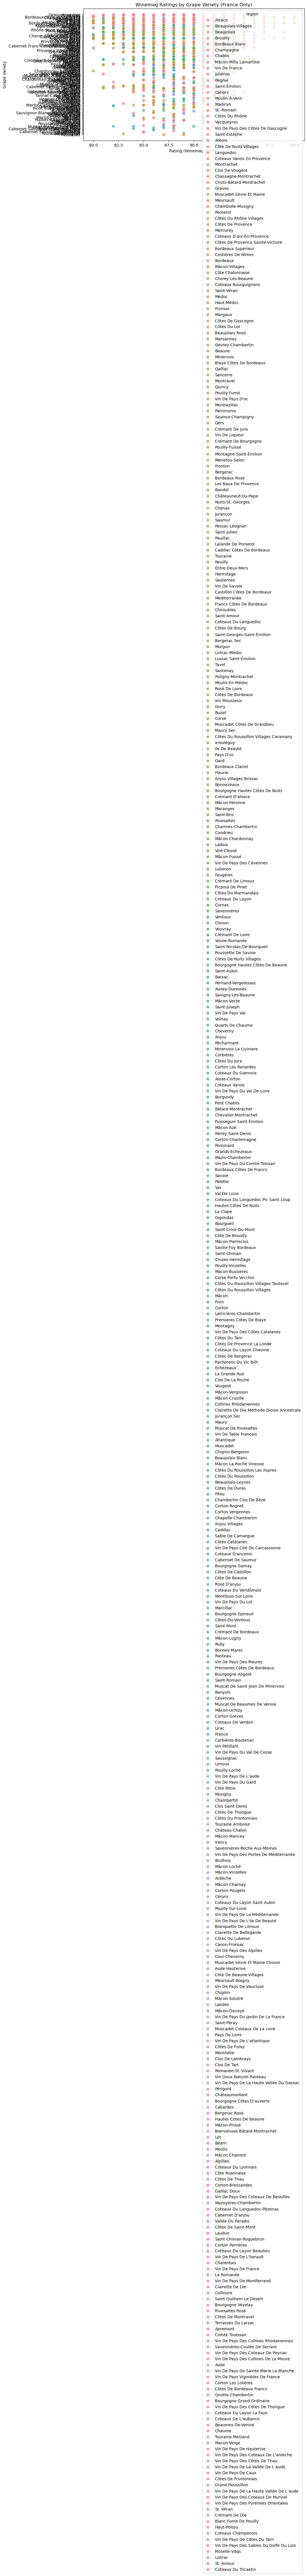

In [21]:
# Filter Winemag data to French wines only
df_france = conn.execute("""
    SELECT
        variety,
        region_clean AS region,
        points AS rating
    FROM winemag_clean
    WHERE country = 'France'
      AND variety IS NOT NULL
      AND rating IS NOT NULL
      AND region_clean IS NOT NULL
""").df()

# Sort varieties by mean rating for clean plotting
order = (
    df_france.groupby("variety")["rating"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_france,
    x="rating",
    y="variety",
    hue="region",
    alpha=0.7,
    s=60
)

plt.title("Winemag Ratings by Grape Variety (France Only)")
plt.xlabel("Rating (Winemag Points)")
plt.ylabel("Grape Variety")
plt.tight_layout()
plt.show()


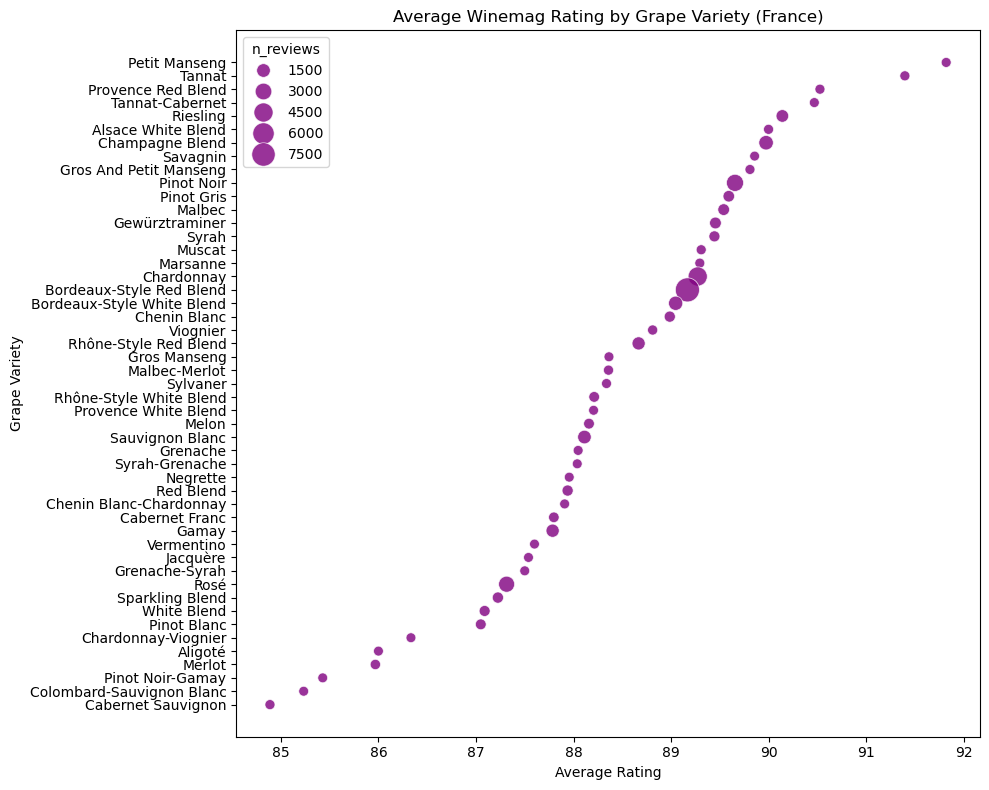

In [22]:
df_avg = conn.execute("""
    SELECT
        variety,
        AVG(points) AS avg_rating,
        COUNT(*) AS n_reviews
    FROM winemag_clean
    WHERE country = 'France'
      AND variety IS NOT NULL
      AND points IS NOT NULL
    GROUP BY variety
    HAVING COUNT(*) > 20
    ORDER BY avg_rating DESC
""").df()

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_avg,
    x="avg_rating",
    y="variety",
    size="n_reviews",
    sizes=(50, 300),
    color="purple",
    alpha=0.8
)

plt.title("Average Winemag Rating by Grape Variety (France)")
plt.xlabel("Average Rating")
plt.ylabel("Grape Variety")
plt.tight_layout()
plt.show()


In [23]:
# Try to join tables to get average score by wine variety, type, french
df_avg = conn.execute("""
    SELECT
        w.variety,
        AVG(w.points) AS avg_rating,
        COUNT(*) AS n_reviews,
        v.wine_type
    FROM winemag_clean w
    JOIN grape_quality_clean g
        ON w.variety = g.variety
    JOIN vivino_clean v
        ON g.region = v.region
    WHERE w.country = 'France'
      AND v.country = 'France'
      AND w.variety IS NOT NULL
      AND v.wine_type IS NOT NULL
    GROUP BY w.variety, v.wine_type
    HAVING COUNT(*) > 20
    ORDER BY avg_rating DESC
""").df()


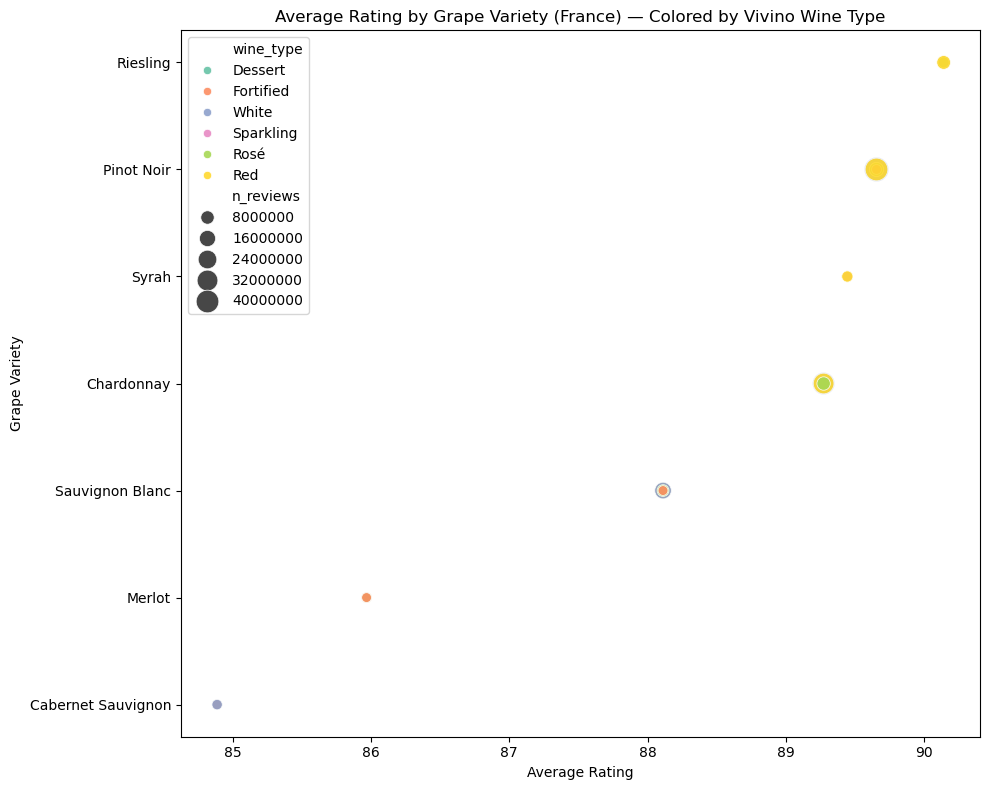

In [24]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_avg,
    x="avg_rating",
    y="variety",
    hue="wine_type",
    size="n_reviews",
    sizes=(50, 300),
    palette="Set2",
    alpha=0.9
)

plt.title("Average Rating by Grape Variety (France) — Colored by Vivino Wine Type")
plt.xlabel("Average Rating")
plt.ylabel("Grape Variety")
plt.tight_layout()
plt.show()


In [25]:
# Boxplot
df_fr = conn.execute("""
    SELECT
        variety,
        points AS rating
    FROM winemag_clean
    WHERE country = 'France'
      AND variety IS NOT NULL
      AND points IS NOT NULL
""").df()



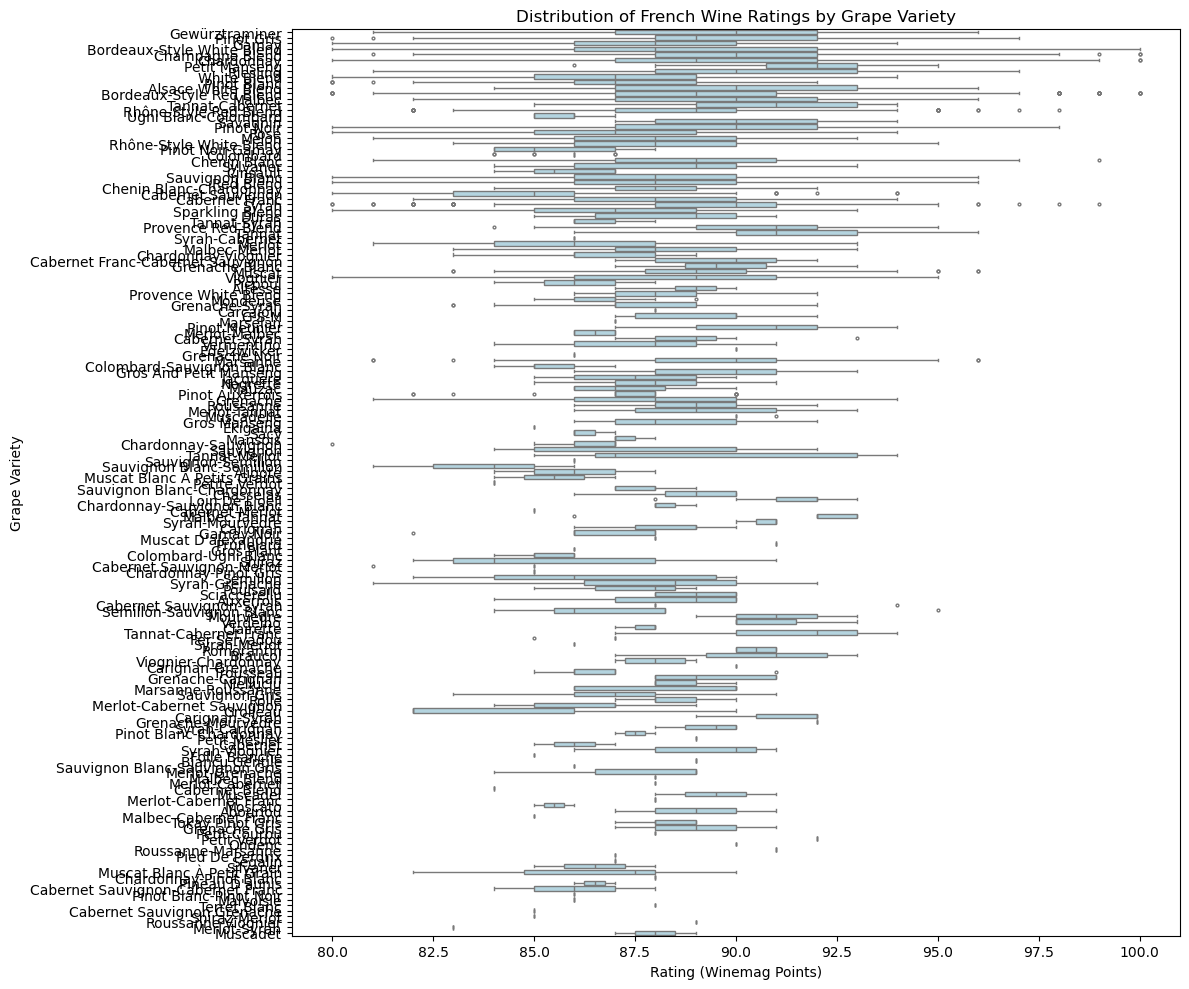

In [26]:
plt.figure(figsize=(12, 10))
sns.boxplot(
    data=df_fr,
    x="rating",
    y="variety",
    color="lightblue",
    fliersize=2
)

plt.title("Distribution of French Wine Ratings by Grape Variety")
plt.xlabel("Rating (Winemag Points)")
plt.ylabel("Grape Variety")
plt.tight_layout()
plt.show()


In [27]:
# Are the highest-rated french grape varieties also the most vulnerable? What does that mean for wine enthusiasts in the years to come?
conn.execute("""
SELECT 
    w.variety,
    AVG(w.points) AS avg_rating,
    AVG(g.sugar_content_brix) AS avg_brix,
    AVG(g.sun_exposure_hours) AS avg_sunlight,
    COUNT(*) AS n_reviews
FROM winemag_clean w
JOIN grape_quality_clean g ON w.variety = g.variety
WHERE w.country = 'France'
GROUP BY w.variety
HAVING COUNT(*) > 30
ORDER BY avg_rating DESC
LIMIT 15
     """)

In [28]:
df = conn.execute("""
SELECT g.*
FROM grape_quality_clean g
JOIN vivino_clean v 
    ON g.region = v.region
WHERE v.country = 'France'
             """).df()

df

,sample_id,variety,region,quality_score,quality_category,sugar_content_brix,acidity_ph,cluster_weight_g,berry_size_mm,harvest_date,sun_exposure_hours,soil_moisture_percent,rainfall_mm
0,2,Pinot Noir,Loire Valley,2.83,High,20.84,3.15,289.00,22.08,2023-09-16,8.8,36.9,312.1
1,14,Merlot,Bordeaux,1.75,Medium,10.79,2.99,155.89,12.90,2023-09-20,9.8,50.1,314.9
2,18,Zinfandel,Bordeaux,2.66,High,21.36,4.06,171.36,23.44,2023-09-11,7.9,51.9,247.1
3,21,Syrah,Loire Valley,2.75,High,23.95,4.15,135.73,16.17,2023-08-18,10.0,46.7,530.4
4,28,Chardonnay,Bordeaux,2.05,Medium,26.89,4.17,242.52,12.34,2023-08-20,6.3,35.2,790.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
183185,979,Zinfandel,Bordeaux,2.51,High,27.45,3.79,65.17,10.01,2023-09-10,9.2,60.8,639.0
183186,984,Sauvignon Blanc,Bordeaux,2.32,Medium,19.66,3.94,117.82,22.59,2023-08-16,6.3,63.4,331.8
183187,989,Chardonnay,Bordeaux,2.84,High,18.74,3.81,151.24,20.97,2023-08-16,10.0,36.3,675.3
183188,992,Pinot Noir,Bordeaux,2.21,Medium,13.18,3.92,113.34,18.60,2023-08-20,9.3,39.6,337.1


In [29]:
# Check regions
df = conn.execute("""
SELECT g.region, COUNT(*) as n
FROM grape_quality_clean g
JOIN vivino_clean v ON g.region = v.region
WHERE v.country = 'France'
GROUP BY g.region
                  """).df()
df

,region,n
0,Loire Valley,78120
1,Bordeaux,105070


In [30]:
df = conn.execute("""
-- See what's actually in each table
SELECT DISTINCT region FROM grape_quality_clean ORDER BY region;
SELECT DISTINCT region FROM vivino_clean WHERE country = 'France' ORDER BY region;
                  """).df()
df

,region
0,Alsace
1,Bordeaux
2,Bourgogne
3,Chablis
4,Champagne
5,Côte De Beaune
6,Loire Valley
7,Pessac-Léognan
8,Rhone Valley


In [31]:
conn.execute("""
    SELECT 
        g.region,
        g.variety,
        AVG(g.sugar_content_brix) AS avg_brix,
        AVG(g.acidity_ph) AS avg_ph,
        AVG(g.soil_moisture_percent) AS avg_moisture,
        AVG(w.points) AS avg_rating,
        COUNT(*) AS n
    FROM grape_quality_clean g
    JOIN winemag_clean w ON g.variety = w.variety 
                         AND w.country = 'France'
    WHERE g.region IN ('Bordeaux', 'Loire Valley')
    GROUP BY g.region, g.variety
    HAVING COUNT(*) > 30
    ORDER BY avg_rating DESC
""").df()

,region,variety,avg_brix,avg_ph,avg_moisture,avg_rating,n
0,Loire Valley,Riesling,20.155714,3.641429,49.071429,90.141627,7315
1,Bordeaux,Riesling,17.533333,3.572222,44.822222,90.141627,18810
2,Loire Valley,Pinot Noir,20.563462,3.556538,54.523077,89.655934,84786
3,Bordeaux,Pinot Noir,21.995714,3.626667,52.509524,89.655934,68481
4,Bordeaux,Syrah,19.396923,3.441538,47.146154,89.444965,5551
5,Loire Valley,Syrah,21.349000,3.669000,49.960000,89.444965,4270
6,Loire Valley,Chardonnay,18.091333,3.393333,47.580000,89.273516,67455
7,Bordeaux,Chardonnay,19.824167,3.867500,48.400000,89.273516,53964
8,Bordeaux,Sauvignon Blanc,20.314500,3.488500,48.040000,88.112252,29220
9,Loire Valley,Sauvignon Blanc,18.032500,3.616000,44.920000,88.112252,29220


In [32]:
conn.execute("""
    SELECT DISTINCT variety
    FROM grape_quality_clean
    WHERE region IN ('Bordeaux', 'Loire Valley')
    ORDER BY variety
""").df()

,variety
0,Cabernet Sauvignon
1,Chardonnay
2,Merlot
3,Pinot Noir
4,Riesling
5,Sauvignon Blanc
6,Syrah
7,Zinfandel


In [33]:
df = conn.execute("""
    SELECT 
        region,
        variety,
        AVG(sugar_content_brix) AS avg_brix,
        AVG(acidity_ph) AS avg_ph,
        AVG(soil_moisture_percent) AS avg_moisture,
        AVG(rainfall_mm) AS avg_rainfall
    FROM grape_quality_clean
    WHERE region IN ('Bordeaux', 'Loire Valley')
      AND variety != 'Zinfandel'
    GROUP BY region, variety
""").df()
df

,region,variety,avg_brix,avg_ph,avg_moisture,avg_rainfall
0,Bordeaux,Pinot Noir,21.995714,3.626667,52.509524,495.147619
1,Bordeaux,Syrah,19.396923,3.441538,47.146154,460.246154
2,Bordeaux,Cabernet Sauvignon,19.613077,3.638462,47.484615,460.423077
3,Loire Valley,Pinot Noir,20.563462,3.556538,54.523077,483.938462
4,Loire Valley,Riesling,20.155714,3.641429,49.071429,515.900000
5,Bordeaux,Merlot,20.417500,3.507500,46.868750,531.481250
6,Loire Valley,Chardonnay,18.091333,3.393333,47.580000,452.433333
7,Bordeaux,Sauvignon Blanc,20.314500,3.488500,48.040000,512.010000
8,Loire Valley,Syrah,21.349000,3.669000,49.960000,442.680000
9,Bordeaux,Riesling,17.533333,3.572222,44.822222,429.416667


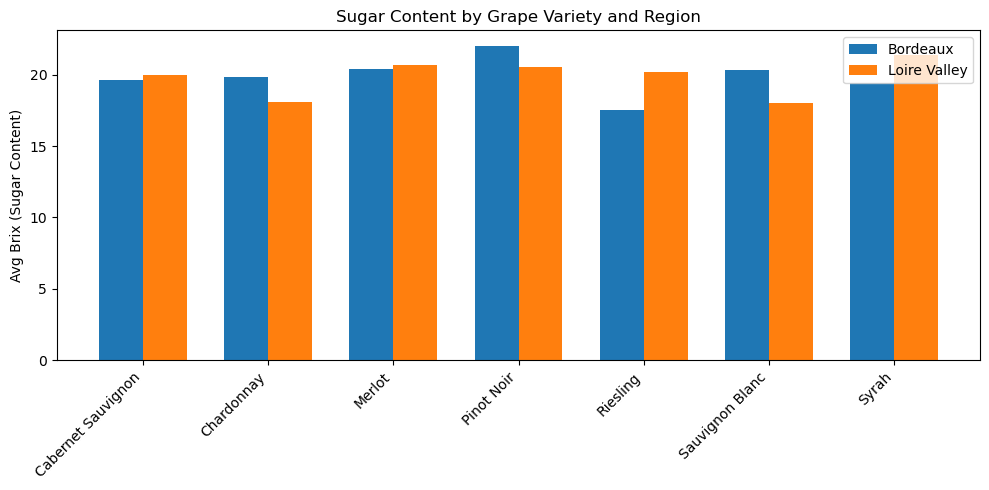

In [34]:
import matplotlib.pyplot as plt
import numpy as np

varieties = sorted(df['variety'].unique())
regions = sorted(df['region'].unique())
x = np.arange(len(varieties))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

for i, region in enumerate(regions):
    subset = df[df['region'] == region].set_index('variety').reindex(varieties)
    ax.bar(x + i*width, subset['avg_brix'], width, label=region)

ax.set_xticks(x + width/2)
ax.set_xticklabels(varieties, rotation=45, ha='right')
ax.set_ylabel('Avg Brix (Sugar Content)')
ax.set_title('Sugar Content by Grape Variety and Region')
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
# Boxplot
df_raw = conn.execute("""
    SELECT 
        region,
        variety,
        sugar_content_brix,
        soil_moisture_percent,
        acidity_ph
    FROM grape_quality_clean
    WHERE region IN ('Bordeaux', 'Loire Valley')
      AND variety != 'Zinfandel'
""").df()

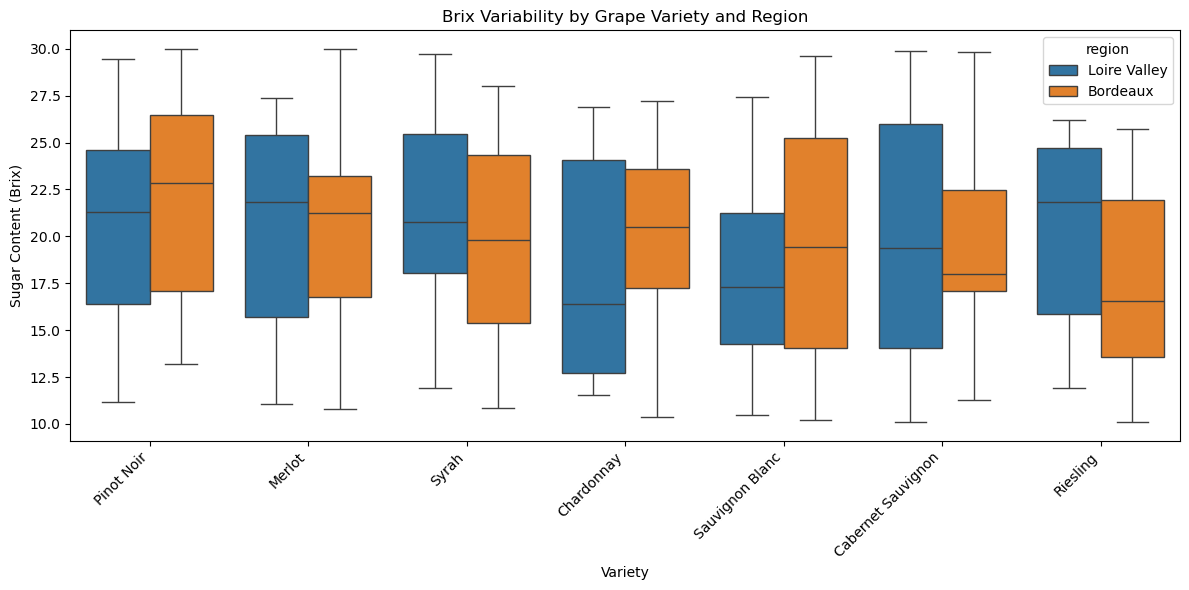

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_raw, x='variety', y='sugar_content_brix', hue='region', ax=ax)

ax.set_title('Brix Variability by Grape Variety and Region')
ax.set_xlabel('Variety')
ax.set_ylabel('Sugar Content (Brix)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [37]:
conn.execute("DESCRIBE vivino_clean").df()

,column_name,column_type,null,key,default,extra
0,country,VARCHAR,YES,None,None,None
1,rating,DOUBLE,YES,None,None,None
2,wine_name,VARCHAR,YES,None,None,None
3,winery_name,VARCHAR,YES,None,None,None
4,ratings_count,INTEGER,YES,None,None,None
5,wine_type,VARCHAR,YES,None,None,None
6,region,VARCHAR,YES,None,None,None
7,is_natural,BOOLEAN,YES,None,None,None


In [38]:
conn.execute("DESCRIBE winemag_clean").df()

,column_name,column_type,null,key,default,extra
0,variety,VARCHAR,YES,None,None,None
1,winery,VARCHAR,YES,None,None,None
2,country,VARCHAR,YES,None,None,None
3,province,VARCHAR,YES,None,None,None
4,region_1,VARCHAR,YES,None,None,None
5,region_2,VARCHAR,YES,None,None,None
6,points,BIGINT,YES,None,None,None
7,price,DOUBLE,YES,None,None,None
8,region_clean,VARCHAR,YES,None,None,None


In [39]:
conn.execute("""
    SELECT MIN(price), MAX(price), AVG(price), COUNT(*)
    FROM winemag_clean
    WHERE price IS NOT NULL
""").df()

,min(price),max(price),avg(price),count_star()
0,4.0,3300.0,34.749542,200724


In [40]:
conn.execute("""
    SELECT
        country,
        variety,
        price,
        points,
        winery
    FROM winemag_clean
    WHERE price IS NOT NULL
      AND points IS NOT NULL
      AND country IN ('France', 'Italy', 'US', 'Spain', 'Argentina')
    
""").df()

,country,variety,price,points,winery
0,Spain,Tempranillo-Merlot,15.0,87,Tandem
1,Italy,Frappato,16.0,87,Terre Di Giurfo
2,France,Gewürztraminer,24.0,87,Trimbach
3,France,Pinot Gris,27.0,87,Jean-Baptiste Adam
4,France,Gewürztraminer,30.0,87,Leon Beyer
...,...,...,...,...,...
72468,Spain,Albariño,17.0,89,Nessa
72469,Italy,Carricante,80.0,89,Benanti
72470,Italy,Grillo,15.0,89,Caruso & Minini
72471,Italy,Nerello Mascalese,52.0,89,Cottanera


In [41]:
# See wine cost
conn.execute("""
    SELECT MIN(price), MAX(price), AVG(price), COUNT(*)
    FROM winemag_clean
    WHERE price IS NOT NULL
      AND price <= 200
""").df()

,min(price),max(price),avg(price),count_star()
0,4.0,200.0,32.78307,199539


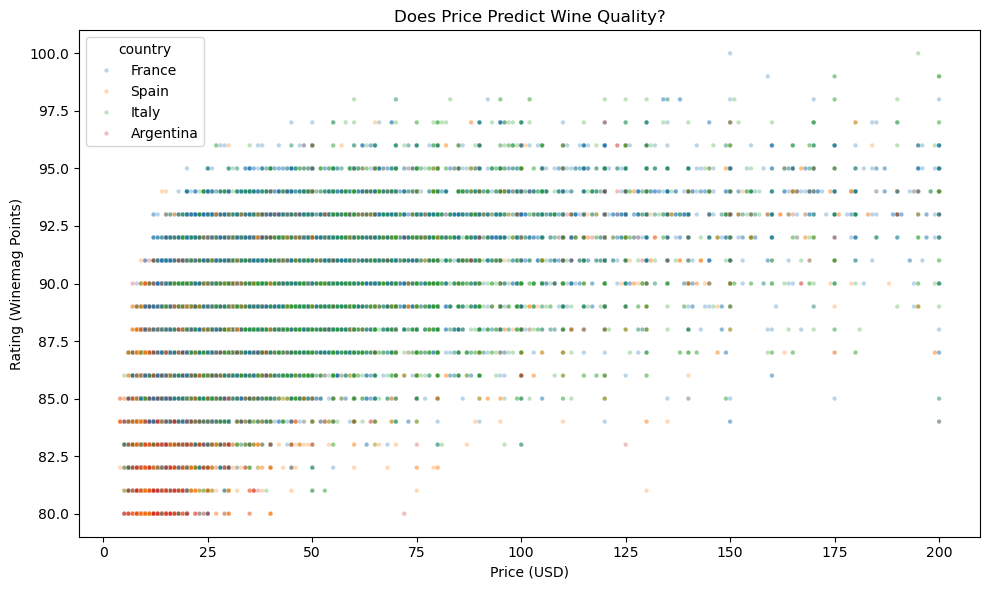

In [42]:
df_price = conn.execute("""
    SELECT country, variety, price, points
    FROM winemag_clean
    WHERE price IS NOT NULL
      AND points IS NOT NULL
      AND price <= 200
      AND country IN ('France', 'Italy', 'US', 'Spain', 'Argentina')
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_price,
    x='price',
    y='points',
    hue='country',
    alpha=0.3,
    s=10,
    ax=ax
)

ax.set_title('Does Price Predict Wine Quality?')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Rating (Winemag Points)')
plt.tight_layout()
plt.show()

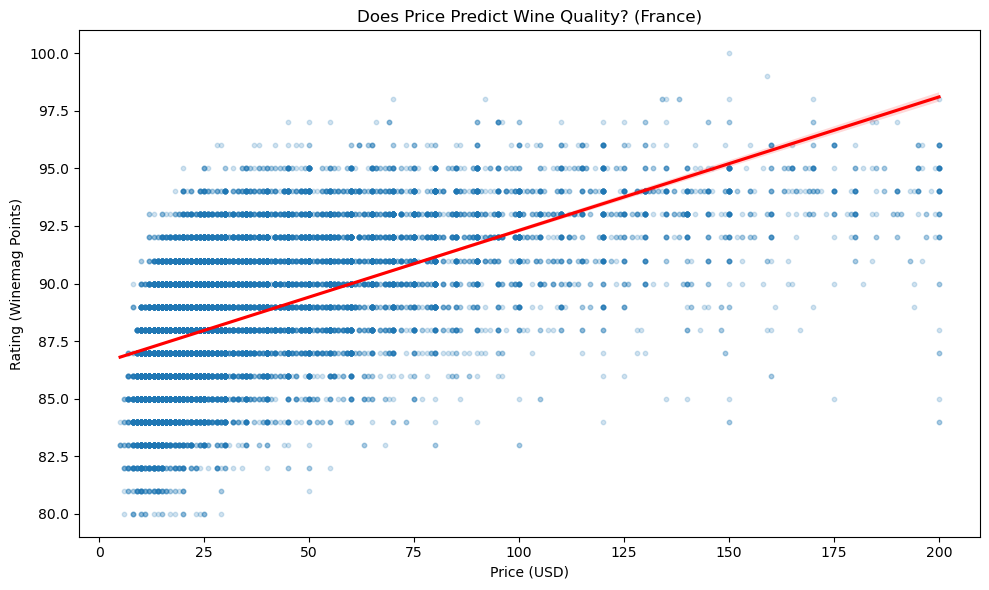

In [43]:
df_france = conn.execute("""
    SELECT variety, price, points
    FROM winemag_clean
    WHERE price IS NOT NULL
      AND points IS NOT NULL
      AND price <= 200
      AND country = 'France'
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=df_france,
    x='price',
    y='points',
    scatter_kws={'alpha': 0.2, 's': 10},
    line_kws={'color': 'red'},
    ax=ax
)

ax.set_title('Does Price Predict Wine Quality? (France)')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Rating (Winemag Points)')
plt.tight_layout()
plt.show()

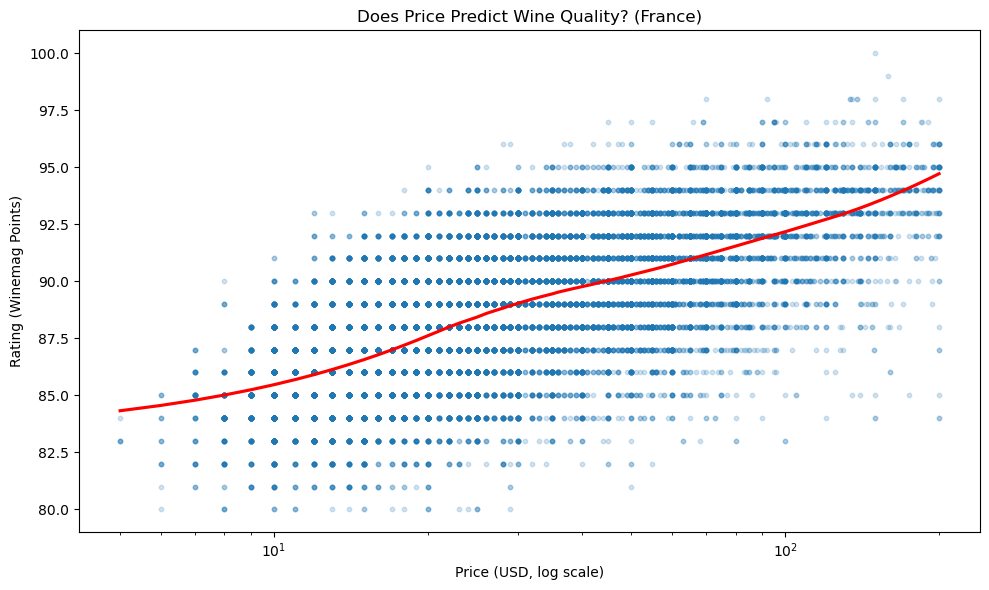

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=df_france,
    x='price',
    y='points',
    scatter_kws={'alpha': 0.2, 's': 10},
    line_kws={'color': 'red'},
    lowess=True,
    ax=ax
)

ax.set_xscale('log')
ax.set_title('Does Price Predict Wine Quality? (France)')
ax.set_xlabel('Price (USD, log scale)')
ax.set_ylabel('Rating (Winemag Points)')
plt.tight_layout()
plt.show()

In [55]:
df_value = conn.execute("""
    SELECT variety, price, points, winery
    FROM winemag_clean
    WHERE country = 'France'
      AND points >= 90
      AND price <= 20
      AND price IS NOT NULL
      AND variety IS NOT NULL
    ORDER BY points DESC, price ASC
""").df()

print(df_value['variety'].nunique())
df_value.head(10)

60


,variety,price,points,winery
0,Red Blend,20.0,95,Alain Brumont
1,Petit Manseng,18.0,94,Domaine Cauhapé
2,Malbec,20.0,94,Château Du Cèdre
3,Red Blend,20.0,94,Alain Brumont
4,Rosé,20.0,94,Château Vignelaure
5,Gamay,20.0,94,Domaines Dominique Piron
6,White Blend,20.0,94,Domaine Marcel Deiss
7,Red Blend,20.0,94,Alain Brumont
8,Malbec,20.0,94,Château Du Cèdre
9,Rosé,20.0,94,Château Vignelaure


C:\Users\joshu\AppData\Local\Temp\ipykernel_29244\3772354999.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['points_jittered'] = df_plot['points'] + np.random.uniform(-0.3, 0.3, len(df_plot))
C:\Users\joshu\AppData\Local\Temp\ipykernel_29244\3772354999.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['price_jittered'] = df_plot['price'] + np.random.uniform(-0.3, 0.3, len(df_plot))


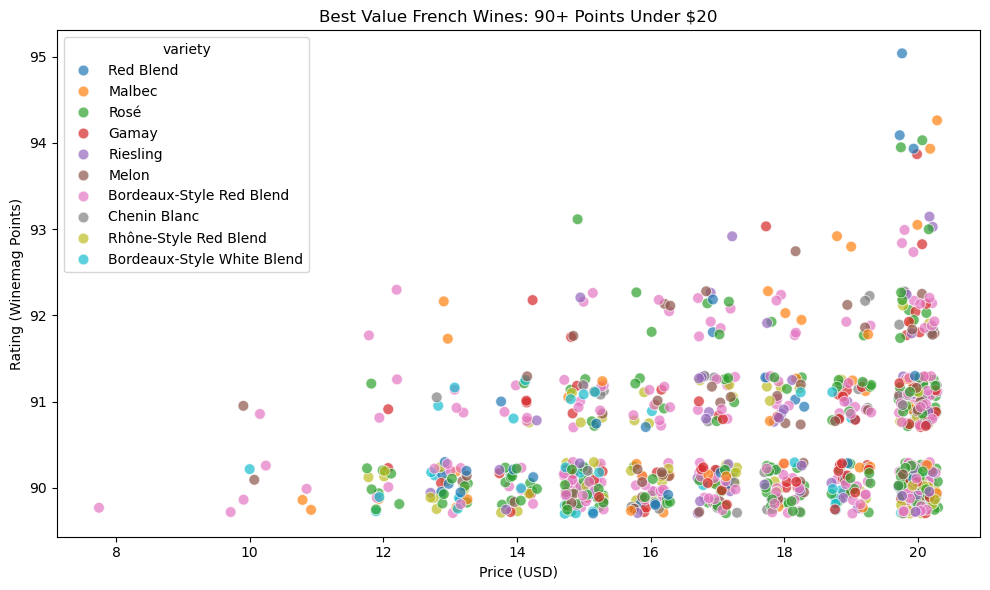

In [57]:
import numpy as np

df_plot['points_jittered'] = df_plot['points'] + np.random.uniform(-0.3, 0.3, len(df_plot))
df_plot['price_jittered'] = df_plot['price'] + np.random.uniform(-0.3, 0.3, len(df_plot))

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x='price_jittered',
    y='points_jittered',
    hue='variety',
    alpha=0.7,
    s=60,
    ax=ax
)

ax.set_title('Best Value French Wines: 90+ Points Under $20')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Rating (Winemag Points)')
plt.tight_layout()
plt.show()

In [45]:
conn.execute("""
-- See what's actually in each table
SELECT DISTINCT region FROM grape_quality_clean ORDER BY region;
SELECT DISTINCT region FROM vivino_clean WHERE country = 'France' ORDER BY region;
             """)

In [46]:
conn.execute("""
-- See what's actually in each table
SELECT DISTINCT region FROM grape_quality_clean ORDER BY region;
SELECT DISTINCT region FROM vivino_clean WHERE country = 'France' ORDER BY region;
             """)

In [47]:
# List tables to confirm connection
conn.execute("SHOW TABLES").fetchall()

[('grape_quality_clean',), ('vivino_clean',), ('winemag_clean',)]

In [48]:
grapes = conn.table("grape_quality_clean")
grapes


┌───────────┬────────────────────┬────────────────┬───────────────┬──────────────────┬────────────────────┬────────────┬──────────────────┬───────────────┬──────────────┬────────────────────┬───────────────────────┬─────────────┐
│ sample_id │      variety       │     region     │ quality_score │ quality_category │ sugar_content_brix │ acidity_ph │ cluster_weight_g │ berry_size_mm │ harvest_date │ sun_exposure_hours │ soil_moisture_percent │ rainfall_mm │
│   int32   │      varchar       │    varchar     │    double     │     varchar      │       double       │   double   │      double      │    double     │     date     │       double       │        double         │   double    │
├───────────┼────────────────────┼────────────────┼───────────────┼──────────────────┼────────────────────┼────────────┼──────────────────┼───────────────┼──────────────┼────────────────────┼───────────────────────┼─────────────┤
│         1 │ Riesling           │ Barossa Valley │          2.11 │ Medium      

In [49]:
vivino = conn.table("vivino_clean")
vivino

┌───────────┬────────┬───────────────────────────────────────┬───────────────┬───────────────┬───────────┬──────────────────┬────────────┐
│  country  │ rating │               wine_name               │  winery_name  │ ratings_count │ wine_type │      region      │ is_natural │
│  varchar  │ double │                varchar                │    varchar    │     int32     │  varchar  │     varchar      │  boolean   │
├───────────┼────────┼───────────────────────────────────────┼───────────────┼───────────────┼───────────┼──────────────────┼────────────┤
│ Chile     │    3.9 │ Reserva Especial Carménère            │ Terranoble    │           341 │ Red       │ Aconcagua Valley │ false      │
│ Australia │    3.3 │ Regional Series Chardonnay            │ Lindeman's    │           666 │ White     │ Adelaide Hills   │ false      │
│ Argentina │    3.6 │ Alto Agrelo Grande Reserve Malbec     │ Alta Vista    │           154 │ Red       │ Agrelo           │ false      │
│ Argentina │    4.0 │ Lote

In [50]:
winemag = conn.table("winemag_clean")
winemag

┌────────────────────┬──────────────────────┬─────────────┬───────────────────┬──────────────────────┬───────────────────┬────────┬────────┬──────────────────────┐
│      variety       │        winery        │   country   │     province      │       region_1       │     region_2      │ points │ price  │     region_clean     │
│      varchar       │       varchar        │   varchar   │      varchar      │       varchar        │      varchar      │ int64  │ double │       varchar        │
├────────────────────┼──────────────────────┼─────────────┼───────────────────┼──────────────────────┼───────────────────┼────────┼────────┼──────────────────────┤
│ White Blend        │ Nicosia              │ Italy       │ Sicily & Sardinia │ Etna                 │ NULL              │     87 │   NULL │ Etna                 │
│ Portuguese Red     │ Quinta Dos Avidagos  │ Portugal    │ Douro             │ NULL                 │ NULL              │     87 │   15.0 │ NULL                 │
│ Pinot Gris    

In [51]:
cur.execute("""
    SELECT DISTINCT region
    FROM vivino_clean
    WHERE country = 'France'
    ORDER BY region;
""")

regions = cur.df()
regions

,region
0,Alsace
1,Bordeaux
2,Bourgogne
3,Chablis
4,Champagne
5,Côte De Beaune
6,Loire Valley
7,Pessac-Léognan
8,Rhone Valley


In [52]:
cur.execute("""
    SELECT
        v.country,
        v.region,
        v.wine_type,
        AVG(g.sugar_content_brix) AS avg_brix,
        COUNT(*) AS n_samples
    FROM grape_quality_clean g
    JOIN vivino_clean v
        ON g.region = v.region
    GROUP BY
        v.country,
        v.region,
        v.wine_type
    HAVING COUNT(*) > 5
    ORDER BY avg_brix DESC
""")

df = cur.df()
df.head()


,country,region,wine_type,avg_brix,n_samples
0,Argentina,Mendoza,Dessert,20.354308,910
1,Argentina,Mendoza,Rosé,20.354308,1560
2,Argentina,Mendoza,White,20.354308,7540
3,Argentina,Mendoza,Sparkling,20.354308,3770
4,Argentina,Mendoza,Red,20.354308,26260


In [53]:
cur.execute("""
    SELECT
        region,
        wine_type,
        AVG(rating) AS avg_rating,
        COUNT(*) AS n_wines
    FROM vivino_clean
    WHERE country = 'France'
    GROUP BY region, wine_type
    HAVING COUNT(*) > 10
    ORDER BY avg_rating DESC
""")

df = cur.df()
df.head()


,region,wine_type,avg_rating,n_wines
0,Alsace,Dessert,4.208333,48
1,Champagne,Sparkling,4.201940,2886
2,Côte De Beaune,White,4.168750,16
3,Champagne,Fortified,4.126667,15
4,Champagne,Dessert,4.113333,15


In [54]:
merged = gdf.merge(regions, on="admin_region", how="right")
merged


KeyError: 'admin_region'

In [59]:
# Close the connection
conn.close()